In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# from overt_reading_process import HS_block_erps
# from xgboost import XGBClassifier


# Print the current working directory.
import warnings

warnings.filterwarnings("ignore")

# cc_path = clean_data_path+'cross_correlation_by_cluster/'
HS_list = [ 45, 47, 48, 50, 54, 71, 73, 76,78]

In [2]:

bands = {
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta1': (12, 24),
    'beta2': (24, 40),
    'low_gamma': (40, 70),
    'high_gamma': (70, 150)
}

band = 'beta1'

# Fig. 3k

POCG-SMG → subCG: N=85, Mean=-21 ms, SD=112 ms
POCG-SMG → mPMC: N=227, Mean=-67 ms, SD=82 ms
subCG → mPMC: N=259, Mean=-38 ms, SD=87 ms
POCG-SMG → SA-spe: N=456, Mean=-58 ms, SD=150 ms
subCG → SA-spe: N=1105, Mean=-53 ms, SD=141 ms
mPMC → SA-spe: N=1563, Mean=-2 ms, SD=148 ms


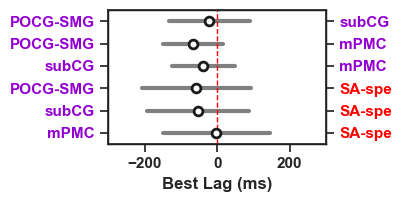

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['font.weight'] = 'bold'

labels_map = {
    "mPrCG": "mPMC",
    "vPrCG": "subCG",
    "POCG-SMG": "POCG-SMG",
    "SA-spe": "SA-spe"
}

colors_map = {
    "mPrCG": "#9300D1",
    "vPrCG": "#9300D1",
    "POCG-SMG": "#9300D1",
    "SA-spe": "red"
}

cluster_map = {
    "shared_0": "mPrCG",
    "shared_1": "vPrCG", 
    "shared_2": "POCG-SMG",
    "SI_0": "SI-spe",
    "SA_0": "SA-spe"
}

test_col = 'new_cluster'

reverse_cluster_map = {v: k for k, v in cluster_map.items()}

cluster_pair = [
    ("POCG-SMG", "vPrCG"),
    ("POCG-SMG", "mPrCG"),
    ("vPrCG", "mPrCG"),
    ("POCG-SMG", "SA-spe"),
    ("vPrCG", "SA-spe"),
    ("mPrCG", "SA-spe"),
]

# ==========================
# Read the Source Data workbook.
# ==========================

test_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 3k-l"
)

fig, ax = plt.subplots(figsize=(4,2))

y_positions = np.arange(len(cluster_pair))

for idx, (c1, c2) in enumerate(cluster_pair):

    subset = test_df[
        (test_df[f"{test_col}1"] == reverse_cluster_map[c1]) &
        (test_df[f"{test_col}2"] == reverse_cluster_map[c2])
    ]

    if subset.empty:
        continue

    lags = subset["best_lag"].values * 10

    mean = np.mean(lags)
    std = np.std(lags, ddof=1)
    print(
        f"{labels_map[c1]} → {labels_map[c2]}: "
        f"N={len(lags)}, "
        f"Mean={mean:.0f} ms, "
        f"SD={std:.0f} ms"
    )

    ax.plot(
        [mean-std, mean+std],
        [idx, idx],
        color="gray",
        lw=3,
        zorder=2
    )

    ax.scatter(
        mean,
        idx,
        facecolors="white",
        edgecolors="k",
        s=40,
        lw=2,
        zorder=3
    )

y_labels_left = [
    labels_map[c1]
    for c1, c2 in cluster_pair
]

y_labels_right = [
    labels_map[c2]
    for c1, c2 in cluster_pair
]

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels_left)

for label, (c1, _) in zip(ax.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c1])

ax_right = ax.twinx()

ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(y_labels_right)

for label, (_, c2) in zip(ax_right.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c2])

ax.set_xlabel("Best Lag (ms)", fontweight="bold")

ax.set_xlim(-300,300)

ax.set_ylim(-0.5, len(cluster_pair)-0.5)
ax_right.set_ylim(-0.5, len(cluster_pair)-0.5)

ax.invert_yaxis()
ax_right.invert_yaxis()

ax.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1
)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig. 3k.tiff",
    dpi=300
)

plt.show()

# Fig. 3n

POCG-SMG → subCG: N=72, Mean=-19 ms, SD=151 ms
POCG-SMG → mPMC: N=164, Mean=-50 ms, SD=113 ms
subCG → mPMC: N=185, Mean=-39 ms, SD=83 ms
POCG-SMG → SI-spe: N=117, Mean=-53 ms, SD=139 ms
subCG → SI-spe: N=165, Mean=-33 ms, SD=153 ms
mPMC → SI-spe: N=321, Mean=-43 ms, SD=189 ms


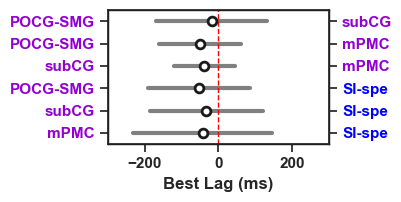

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['font.weight'] = 'bold'

labels_map = {
    "mPrCG": "mPMC",
    "vPrCG": "subCG",
    "POCG-SMG": "POCG-SMG",
    "SI-spe": "SI-spe"
}

colors_map = {
    "mPrCG": "#9300D1",
    "vPrCG": "#9300D1",
    "POCG-SMG": "#9300D1",
    "SI-spe": "blue"
}

reverse_cluster_map = {v: k for k, v in cluster_map.items()}

cluster_pair = [
    ("POCG-SMG", "vPrCG"),
    ("POCG-SMG", "mPrCG"),
    ("vPrCG", "mPrCG"),
    ("POCG-SMG", "SI-spe"),
    ("vPrCG", "SI-spe"),
    ("mPrCG", "SI-spe"),
]

# ==========================
# Read the Source Data workbook.
# ==========================

test_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 3n-o"
)

fig, ax = plt.subplots(figsize=(4,2))

y_positions = np.arange(len(cluster_pair))

for idx, (c1, c2) in enumerate(cluster_pair):

    subset = test_df[
        (test_df[f"{test_col}1"] == reverse_cluster_map[c1]) &
        (test_df[f"{test_col}2"] == reverse_cluster_map[c2])
    ]

    if subset.empty:
        continue

    lags = subset["best_lag"].values * 10

    mean = np.mean(lags)
    std = np.std(lags, ddof=1)
    
    print(
        f"{labels_map[c1]} → {labels_map[c2]}: "
        f"N={len(lags)}, "
        f"Mean={mean:.0f} ms, "
        f"SD={std:.0f} ms"
    )
    
    ax.plot(
        [mean-std, mean+std],
        [idx, idx],
        color="gray",
        lw=3,
        zorder=2
    )

    ax.scatter(
        mean,
        idx,
        facecolors="white",
        edgecolors="k",
        s=40,
        lw=2,
        zorder=3
    )

y_labels_left = [
    labels_map[c1]
    for c1, c2 in cluster_pair
]

y_labels_right = [
    labels_map[c2]
    for c1, c2 in cluster_pair
]

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels_left)

for label, (c1, _) in zip(ax.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c1])

ax_right = ax.twinx()

ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(y_labels_right)

for label, (_, c2) in zip(ax_right.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c2])

ax.set_xlabel("Best Lag (ms)", fontweight="bold")

ax.set_xlim(-300,300)

ax.set_ylim(-0.5, len(cluster_pair)-0.5)
ax_right.set_ylim(-0.5, len(cluster_pair)-0.5)

ax.invert_yaxis()
ax_right.invert_yaxis()

ax.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1
)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig. 3n.tiff",
    dpi=300
)

plt.show()

# Fig. 3l

POCG-SMG → subCG: N=85, Mean=0.78, SD=0.13
POCG-SMG → mPMC: N=227, Mean=0.83, SD=0.07
subCG → mPMC: N=259, Mean=0.86, SD=0.07
POCG-SMG → SA-spe: N=456, Mean=0.79, SD=0.13
subCG → SA-spe: N=1105, Mean=0.81, SD=0.16
mPMC → SA-spe: N=1563, Mean=0.80, SD=0.15


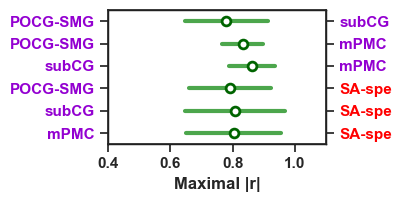

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="ticks")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['font.weight'] = 'bold'

labels_map = {
    "mPrCG": "mPMC",
    "vPrCG": "subCG",
    "POCG-SMG": "POCG-SMG",
    "SA-spe": "SA-spe"
}

colors_map = {
    "mPrCG": "#9300D1",
    "vPrCG": "#9300D1",
    "POCG-SMG": "#9300D1",
    "SA-spe": "red"
}

reverse_cluster_map = {
    v: k for k, v in cluster_map.items()
}

cluster_pair = [
    ("POCG-SMG","vPrCG"),
    ("POCG-SMG","mPrCG"),
    ("vPrCG","mPrCG"),
    ("POCG-SMG","SA-spe"),
    ("vPrCG","SA-spe"),
    ("mPrCG","SA-spe"),
]

# ==========================
# Read the Source Data workbook.
# ==========================

test_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 3k-l"
)

fig, ax = plt.subplots(figsize=(4,2))

y_positions = np.arange(len(cluster_pair))

for idx, (c1, c2) in enumerate(cluster_pair):

    subset = test_df[
        (test_df[f"{test_col}1"] == reverse_cluster_map[c1]) &
        (test_df[f"{test_col}2"] == reverse_cluster_map[c2])
    ]

    if subset.empty:
        continue

    values = subset["max_r"].values

    mean = np.mean(values)
    std = np.std(values, ddof=1)
    print(
        f"{labels_map[c1]} → {labels_map[c2]}: "
        f"N={len(values)}, "
        f"Mean={mean:.2f}, "
        f"SD={std:.2f}"
    )
    ax.plot(
        [mean-std, mean+std],
        [idx, idx],
        color="green",
        lw=3,
        alpha=0.7,
        zorder=2
    )

    ax.scatter(
        mean,
        idx,
        facecolors="white",
        edgecolors="darkgreen",
        s=40,
        lw=2,
        zorder=3
    )

# Add the left-side label.
y_labels_left = [
    labels_map[c1]
    for c1, c2 in cluster_pair
]

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels_left)

for label, (c1, _) in zip(ax.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c1])

# Add the right-side label.
ax_right = ax.twinx()

y_labels_right = [
    labels_map[c2]
    for c1, c2 in cluster_pair
]

ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(y_labels_right)

for label, (_, c2) in zip(ax_right.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c2])

ax.set_xlabel("Maximal |r|", fontweight="bold")

ax.set_xlim(0.4,1.1)

ax.set_ylim(-0.5, len(cluster_pair)-0.5)
ax_right.set_ylim(-0.5, len(cluster_pair)-0.5)

ax.invert_yaxis()
ax_right.invert_yaxis()

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig. 3l.tiff",
    dpi=300
)

plt.show()

# Fig. 3o

POCG-SMG → subCG: N=72, Mean=0.80, SD=0.08
POCG-SMG → mPMC: N=164, Mean=0.80, SD=0.06
subCG → mPMC: N=185, Mean=0.82, SD=0.10
POCG-SMG → SI-spe: N=117, Mean=0.77, SD=0.14
subCG → SI-spe: N=165, Mean=0.74, SD=0.13
mPMC → SI-spe: N=321, Mean=0.74, SD=0.14


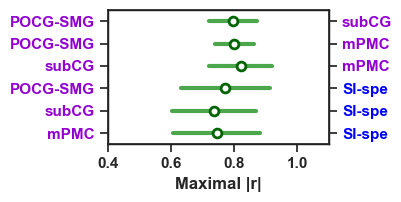

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="ticks")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['font.weight'] = 'bold'

labels_map = {
    "mPrCG": "mPMC",
    "vPrCG": "subCG",
    "POCG-SMG": "POCG-SMG",
    "SI-spe": "SI-spe"
}

colors_map = {
    "mPrCG": "#9300D1",
    "vPrCG": "#9300D1",
    "POCG-SMG": "#9300D1",
    "SI-spe": "blue"
}

reverse_cluster_map = {
    v: k for k, v in cluster_map.items()
}

cluster_pair = [
    ("POCG-SMG","vPrCG"),
    ("POCG-SMG","mPrCG"),
    ("vPrCG","mPrCG"),
    ("POCG-SMG","SI-spe"),
    ("vPrCG","SI-spe"),
    ("mPrCG","SI-spe"),
]

# ==========================
# Read the Source Data workbook.
# ==========================

test_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 3n-o"
)

fig, ax = plt.subplots(figsize=(4,2))

y_positions = np.arange(len(cluster_pair))

for idx, (c1, c2) in enumerate(cluster_pair):

    subset = test_df[
        (test_df[f"{test_col}1"] == reverse_cluster_map[c1]) &
        (test_df[f"{test_col}2"] == reverse_cluster_map[c2])
    ]

    if subset.empty:
        continue

    values = subset["max_r"].values

    mean = np.mean(values)
    std = np.std(values, ddof=1)
    print(
        f"{labels_map[c1]} → {labels_map[c2]}: "
        f"N={len(values)}, "
        f"Mean={mean:.2f}, "
        f"SD={std:.2f}"
    )
    ax.plot(
        [mean-std, mean+std],
        [idx, idx],
        color="green",
        lw=3,
        alpha=0.7,
        zorder=2
    )

    ax.scatter(
        mean,
        idx,
        facecolors="white",
        edgecolors="darkgreen",
        s=40,
        lw=2,
        zorder=3
    )

# Add the left-side label.
y_labels_left = [
    labels_map[c1]
    for c1, c2 in cluster_pair
]

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels_left)

for label, (c1, _) in zip(ax.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c1])

# Add the right-side label.
ax_right = ax.twinx()

y_labels_right = [
    labels_map[c2]
    for c1, c2 in cluster_pair
]

ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(y_labels_right)

for label, (_, c2) in zip(ax_right.get_yticklabels(), cluster_pair):
    label.set_color(colors_map[c2])

ax.set_xlabel("Maximal |r|", fontweight="bold")

ax.set_xlim(0.4,1.1)

ax.set_ylim(-0.5, len(cluster_pair)-0.5)
ax_right.set_ylim(-0.5, len(cluster_pair)-0.5)

ax.invert_yaxis()
ax_right.invert_yaxis()

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig. 3o.tiff",
    dpi=300
)

plt.show()

# Fig. 3m

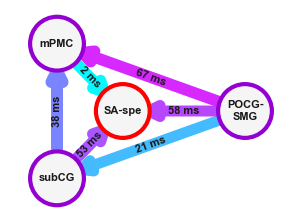

In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6
plt.rcParams["font.weight"] = "normal"

node_map = {
    "mPrCG": "mPMC",
    "vPrCG": "subCG",
    "POCG-SMG": "POCG-\nSMG",
    "SA-spe": "SA-spe"
}

df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 3m"
)

third_node = "SA-spe"

cluster_list = [
    "mPrCG",
    "vPrCG",
    third_node,
    "POCG-SMG"
]

edgecolors = [
    "#9300D1",
    "#9300D1",
    "red",
    "#9300D1"
]

G = nx.DiGraph()

for node in cluster_list:
    G.add_node(node)

edge_labels = {}

for _, row in df.iterrows():

    lag = row["best_lag_mean"] * 10
    r = row["max_r_mean"]

    if lag < 0:
        source, target = row["c1"], row["c2"]
    else:
        source, target = row["c2"], row["c1"]

    G.add_edge(
        source,
        target,
        weight=r,
        color=abs(lag),
        arrow=True
    )

    edge_labels[(source, target)] = f"{abs(lag):.0f} ms"

pos = {
    "mPrCG": (-1, 1),
    "vPrCG": (-1, -1),
    "SA-spe": (-0.3, 0),
    "POCG-SMG": (1, 0)
}

plt.figure(figsize=(3,2.2))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color="whitesmoke",
    node_size=1500,
    edgecolors=edgecolors,
    linewidths=3
)

nx.draw_networkx_labels(
    G,
    pos,
    labels={n: node_map.get(n, n) for n in G.nodes()},
    font_size=8,
    font_weight="bold"
)

for u, v in G.edges():

    edge = G[u][v]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        arrowstyle="-|>",
        arrowsize=20,
        edge_color=[edge["color"]],
        edge_cmap=plt.cm.cool,
        edge_vmin=0,
        edge_vmax=80,
        width=[edge["weight"]*10],
        min_source_margin=10,
        min_target_margin=10
    )

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    font_weight="bold",
    bbox=dict(facecolor="white", edgecolor="white", alpha=0)
)

x_values, y_values = zip(*pos.values())
plt.xlim(min(x_values)-0.5, max(x_values)+0.5)
plt.ylim(min(y_values)-0.5, max(y_values)+0.5)
plt.axis('off')
plt.tight_layout()


plt.savefig(
    clean_data_path + "/figures_R3/Fig. 3m.tiff",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# Fig. 3p

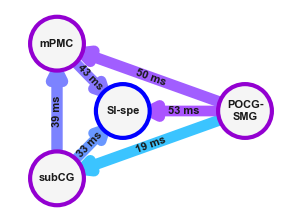

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6
plt.rcParams["font.weight"] = "normal"

node_map = {
    "mPrCG": "mPMC",
    "vPrCG": "subCG",
    "POCG-SMG": "POCG-\nSMG",
    "SI-spe": "SI-spe"
}

df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 3p"
)

third_node = "SI-spe"

cluster_list = [
    "mPrCG",
    "vPrCG",
    third_node,
    "POCG-SMG"
]

edgecolors = [
    "#9300D1",
    "#9300D1",
    "blue",
    "#9300D1"
]

G = nx.DiGraph()

for node in cluster_list:
    G.add_node(node)

edge_labels = {}

for _, row in df.iterrows():

    lag = row["best_lag_mean"] * 10
    r = row["max_r_mean"]

    if lag < 0:
        source, target = row["c1"], row["c2"]
    else:
        source, target = row["c2"], row["c1"]

    G.add_edge(
        source,
        target,
        weight=r,
        color=abs(lag),
        arrow=True
    )

    edge_labels[(source, target)] = f"{abs(lag):.0f} ms"

pos = {
    "mPrCG": (-1, 1),
    "vPrCG": (-1, -1),
    "SI-spe": (-0.3, 0),
    "POCG-SMG": (1, 0)
}

plt.figure(figsize=(3,2.2))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color="whitesmoke",
    node_size=1500,
    edgecolors=edgecolors,
    linewidths=3
)

nx.draw_networkx_labels(
    G,
    pos,
    labels={n: node_map.get(n, n) for n in G.nodes()},
    font_size=8,
    font_weight="bold"
)

for u, v in G.edges():

    edge = G[u][v]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        arrowstyle="-|>",
        arrowsize=20,
        edge_color=[edge["color"]],
        edge_cmap=plt.cm.cool,
        edge_vmin=0,
        edge_vmax=80,
        width=[edge["weight"] * 10],
        min_source_margin=10,
        min_target_margin=10
    )

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    font_weight="bold",
    bbox=dict(facecolor="white", edgecolor="white", alpha=0)
)

x_values, y_values = zip(*pos.values())

plt.xlim(min(x_values)-0.5, max(x_values)+0.5)
plt.ylim(min(y_values)-0.5, max(y_values)+0.5)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig. 3p.tiff",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

<Figure size 100x200 with 0 Axes>

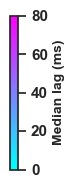

In [9]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['font.weight'] = 'bold'

cmap = plt.cm.cool
norm = mcolors.Normalize(vmin=0, vmax=80)

plt.figure(figsize=(1,2))  # Use a narrow vertical color bar.
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a dedicated axis for the color bar.
fig, ax = plt.subplots(figsize=(3.5, 2))
fig.subplots_adjust(left=0.3, right=0.7)  # Adjust the margins to prevent crowding.
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Median lag (ms)', fontsize=10,fontweight= 'bold')

# Hide the unused axes.
ax.remove()
plt.show()